# Can Machine Learning Predict Gold's Daily Direction?

**Question.** Using only information available at yesterday's London PM fix, can a model predict whether gold's price will rise today, and can that prediction be traded profitably after costs?

**Approach.** 18 years of daily LBMA gold fixes → leakage-free features → four classifiers evaluated with **expanding-window walk-forward validation** (2010 to 2019, about 2,400 unseen days) → a long/cash strategy backtested **with transaction costs** against buy & hold.

**TL;DR.**
* No model beats the naive "always predict up" baseline by more than statistical noise (best: 51.9% ± 2.0% vs 50.9%; ROC AUC ≈ 0.51).
* Before costs, the Random Forest strategy looks attractive: Sharpe 0.53 vs 0.30 for buy & hold, with a shallower drawdown.
* That edge disappears at roughly **3 bps per trade**, because the strategy trades about 90 times a year. At a realistic 5 bps it underperforms buy & hold.
* Year-to-year accuracy swings from 44% to 59%, so the original single-year test (2019) could make the model look good or bad by luck alone.
* So daily gold direction is close to unpredictable from its own price history. The project's value is the evaluation framework that shows this honestly instead of overfitting a single test period.

All logic lives in the tested `goldpred` package. This notebook only orchestrates and visualises it, and the Streamlit app (`app.py`) uses the same code.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from goldpred import FEATURES, MODEL_NAMES, build_features, load_prices, walk_forward
from goldpred.backtest import buy_and_hold, drawdown_curve, equity_curve, performance
from goldpred.report import format_table, strategy_returns, summarize

GOLD, GREY = "#D4A017", "#8C8C8C"
plt.rcParams.update({"figure.figsize": (12, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 4)

## 1. Data

Daily [LBMA gold price](https://www.lbma.org.uk/prices-and-data/precious-metal-prices) fixes in USD, GBP and EUR (AM and PM auctions), January 2001 to September 2019. The **USD PM fix** is the price we predict.

The PM fix isn't held on the last trading day before Christmas and before New Year (usually 24 and 31 December), so those 36 rows have only AM prices. `load_prices` drops them *before* computing returns, so the following day's return is measured from the last real PM fix. (The original version of this project computed returns first. Under pandas 3 that silently discards the return across each holiday gap, and under pandas 2 it fabricates a 0% day, so the results depended on the pandas version.)

In [2]:
raw = pd.read_csv("data/gold_price.csv", parse_dates=["Date"], index_col="Date")
prices = load_prices()
print(f"{len(raw):,} rows, {raw.index.min():%Y-%m-%d} to {raw.index.max():%Y-%m-%d}")
print("Rows without a PM fix:", raw["USD (PM)"].isna().sum(),
      "->", sorted(set(raw.index[raw["USD (PM)"].isna()].strftime("%d %b"))))
prices.head()

4,718 rows, 2001-01-02 to 2019-09-02
Rows without a PM fix: 36 -> ['22 Dec', '23 Dec', '24 Dec', '29 Dec', '30 Dec', '31 Dec']


,USD (AM),USD (PM),GBP (AM),GBP (PM),EURO (AM),EURO (PM)
Date,,,,,,
2001-01-02,272.80,271.10,183.026,181.617,288.677,287.334
2001-01-03,269.00,267.15,178.916,177.390,281.823,281.655
2001-01-04,268.75,267.10,178.869,178.352,282.538,282.049
2001-01-05,268.00,267.40,178.488,178.148,280.775,280.882
2001-01-08,268.60,268.30,178.769,178.664,282.410,282.481


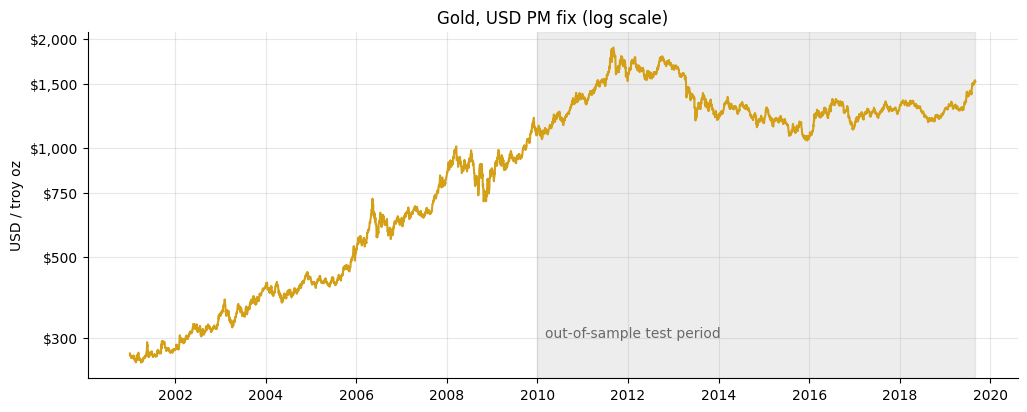

In [3]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices["USD (PM)"], color=GOLD)
ax.set(title="Gold, USD PM fix (log scale)", ylabel="USD / troy oz", yscale="log")
ax.set_yticks([300, 500, 750, 1000, 1500, 2000], labels=["$300", "$500", "$750", "$1,000", "$1,500", "$2,000"])
ax.minorticks_off()
ax.axvspan(pd.Timestamp("2010-01-01"), prices.index.max(), color=GREY, alpha=0.15)
ax.text(pd.Timestamp("2010-03-01"), 300, "out-of-sample test period", color="dimgray")
plt.show()

## 2. Is there anything to predict?

Before modelling, check the two properties that set the ceiling on daily forecasting: how often gold goes up, and whether today's return is correlated with recent returns.

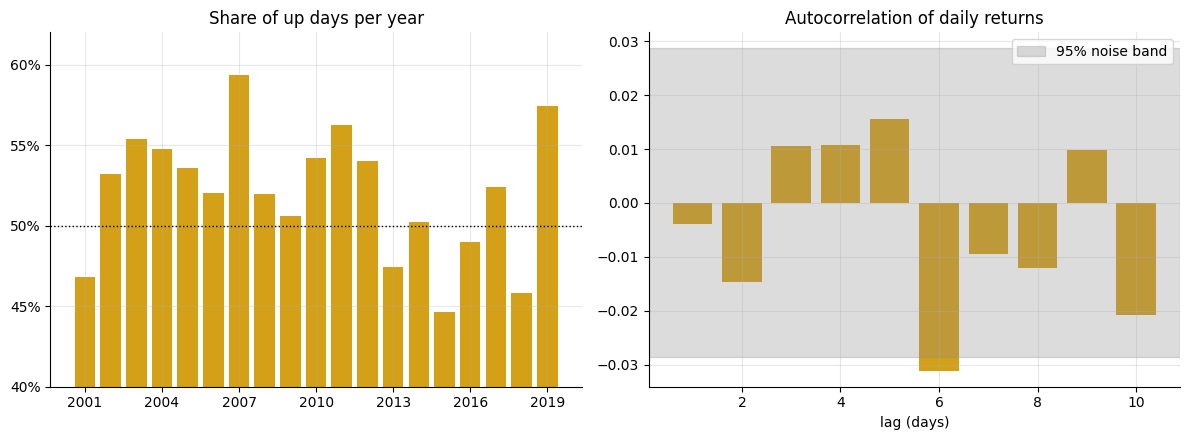

Daily return: mean 0.043%, std 1.10%; up days overall 52.0%


In [4]:
ret = prices["USD (PM)"].pct_change(fill_method=None).dropna()
up_share = (ret > 0).groupby(ret.index.year).mean()
lags = range(1, 11)
autocorr = [ret.autocorr(lag) for lag in lags]
band = 1.96 / np.sqrt(len(ret))

fig, (a1, a2) = plt.subplots(1, 2)
a1.bar(up_share.index, up_share, color=GOLD)
a1.axhline(0.5, color="black", lw=1, ls=":")
a1.set(title="Share of up days per year", ylim=(0.4, 0.62), yticks=np.arange(0.40, 0.61, 0.05))
a1.yaxis.set_major_formatter("{x:.0%}")
a1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
a2.bar(lags, autocorr, color=GOLD)
a2.axhspan(-band, band, color=GREY, alpha=0.3, label="95% noise band")
a2.set(title="Autocorrelation of daily returns", xlabel="lag (days)")
a2.legend()
plt.tight_layout(); plt.show()
print(f"Daily return: mean {ret.mean():.3%}, std {ret.std():.2%}; up days overall {(ret > 0).mean():.1%}")

Gold rises on only about 51 to 52% of days, and past returns are essentially uncorrelated with future ones. Nine of the ten autocorrelations are inside the 95% noise band, and the tenth (lag 6) is only marginally outside, which is what chance alone produces when you test ten lags. That's a strong prior that **any** edge will be small.

### Why classification rather than regression?

The first version of this project regressed the size of the next day's return. With a simple train-on-2001–2009, test-on-2010+ split, both models do *worse* than predicting the average return (negative out-of-sample R²). Predicting the **direction** is a more tractable target, and it maps directly onto a trading decision.

In [5]:
data = build_features(prices)  # default windows: 5 / 20 / 10 days, fixed before testing
train, test = data[data.index.year < 2010], data[data.index.year >= 2010]
for model in [LinearRegression(), RandomForestRegressor(n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=42)]:
    model.fit(train[FEATURES], train["return"])
    print(f"{type(model).__name__:>22}: out-of-sample R² = {r2_score(test['return'], model.predict(test[FEATURES])):+.4f}")

      LinearRegression: out-of-sample R² = -0.0146


 RandomForestRegressor: out-of-sample R² = -0.0254


## 3. Features (no look-ahead)

Row *t* holds features computed from data up to day *t-1*. The target is whether day *t*'s PM fix is above day *t-1*'s.

| Feature | Meaning |
|---|---|
| `ret_lag1/2/3/5` | Return 1, 2, 3 and 5 days ago |
| `trend_short`, `trend_long` | Yesterday's price vs its 5- and 20-day moving average |
| `volatility` | 10-day standard deviation of returns |
| `rsi` | 14-day Relative Strength Index |
| `eurusd_ret_lag1` | Yesterday's EUR/USD move, implied by gold's USD and EUR prices (a weaker dollar tends to lift gold) |

Day *t*'s **AM fix** is deliberately excluded. It is tempting (it's in the same CSV row and correlates strongly with the PM fix), but it is published after the decision point, so using it would leak the answer. `tests/test_data_and_features.py` enforces the rule by changing future prices and asserting that no feature moves.

In [6]:
data[FEATURES].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
ret_lag1,4.3796e-04,0.0110,-0.0915,0.0708
ret_lag2,4.3851e-04,0.0110,-0.0915,0.0708
ret_lag3,4.3862e-04,0.0110,-0.0915,0.0708
ret_lag5,4.3234e-04,0.0110,-0.0915,0.0708
trend_short,7.7839e-04,0.0120,-0.0880,0.0840
trend_long,3.7156e-03,0.0267,-0.1439,0.1114
volatility,9.8535e-03,0.0050,0.0018,0.0402
rsi,5.2785e+01,17.4911,4.8967,99.1910
eurusd_ret_lag1,5.7279e-05,0.0061,-0.0407,0.0443


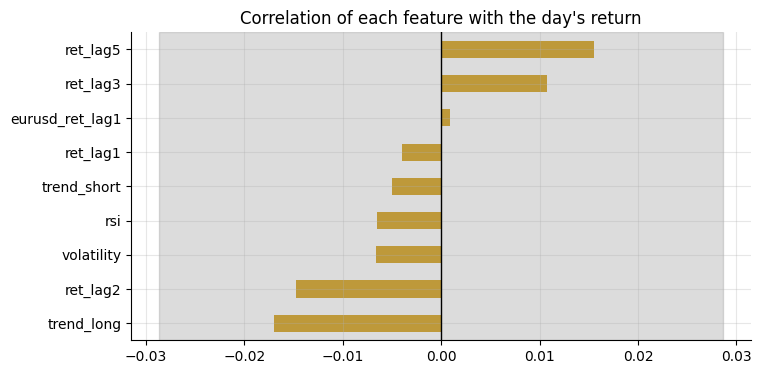

In [7]:
corr = data[FEATURES].corrwith(data["return"]).sort_values()
ax = corr.plot.barh(color=GOLD, figsize=(8, 4), title="Correlation of each feature with the day's return")
ax.axvline(0, color="black", lw=1)
ax.axvspan(-band, band, color=GREY, alpha=0.3)
plt.show()

Every feature's *linear* correlation with the day's return is inside the noise band (grey). Any usable signal would have to come from non-linear combinations of features, which is what the tree-based models get a chance to find.

## 4. Walk-forward evaluation

For each year *Y* from 2010 to 2019, every model is trained on **all data before *Y*** and predicts *Y*. Nothing from the test period ever influences training or hyperparameters: all settings (feature windows, model parameters, 0.5 threshold, 5 bps cost) were fixed before the first evaluation run.

Models compared:
* **Majority class (baseline)**: always predicts the most frequent training direction ("up"), so it is identical to buy & hold.
* **Logistic Regression** (standardised, L2-regularised)
* **Random Forest** (300 trees, min 50 samples per leaf to resist noise)
* **Gradient Boosting** (histogram GBM, depth 3)

In [8]:
oos = {name: walk_forward(data, name, first_test_year=2010) for name in MODEL_NAMES}
n_days = len(next(iter(oos.values())))
print(f"{n_days:,} out-of-sample trading days")

results = {cost: summarize(oos, threshold=0.5, cost_bps=cost) for cost in (0, 5)}
print("\nNo trading costs")
display(format_table(results[0]))
print("\n5 bps per trade")
display(format_table(results[5]))

2,424 out-of-sample trading days

No trading costs


,Accuracy,ROC AUC,CAGR,Sharpe,Max drawdown,Time in market,Trades
Majority class (baseline),50.9% ± 2.0%,0.503,3.6%,0.30,-44.6%,100%,1
Logistic Regression,51.1% ± 2.0%,0.512,3.2%,0.29,-35.5%,87%,463
Random Forest,51.9% ± 2.0%,0.512,6.6%,0.53,-31.4%,76%,843
Gradient Boosting,50.7% ± 2.0%,0.506,5.6%,0.47,-32.6%,70%,973
Buy & hold gold,,,3.6%,0.30,-44.6%,100%,1



5 bps per trade


,Accuracy,ROC AUC,CAGR,Sharpe,Max drawdown,Time in market,Trades
Majority class (baseline),50.9% ± 2.0%,0.503,3.6%,0.30,-44.6%,100%,1
Logistic Regression,51.1% ± 2.0%,0.512,0.8%,0.13,-41.1%,87%,463
Random Forest,51.9% ± 2.0%,0.512,2.0%,0.21,-38.6%,76%,843
Gradient Boosting,50.7% ± 2.0%,0.506,0.3%,0.09,-42.5%,70%,973
Buy & hold gold,,,3.6%,0.30,-44.6%,100%,1


**Reading the table**
* Accuracy is shown with its 95% confidence half-width (about ±2 pp for 2,400 days). Every model's interval overlaps the baseline's, so none of them is a statistically meaningful predictor.
* ROC AUC (which ignores the threshold) is about 0.51 for every model, barely above a coin flip.
* With **zero costs**, the Random Forest and Gradient Boosting strategies improve on buy & hold's Sharpe ratio and drawdown. Most of the Random Forest's pre-cost lead builds up in late 2013 to 2014 and in 2017 to 2018 (see the chart below).
* With **5 bps costs** the picture flips. The strategies trade 460 to 970 times, and those costs eat the edge.

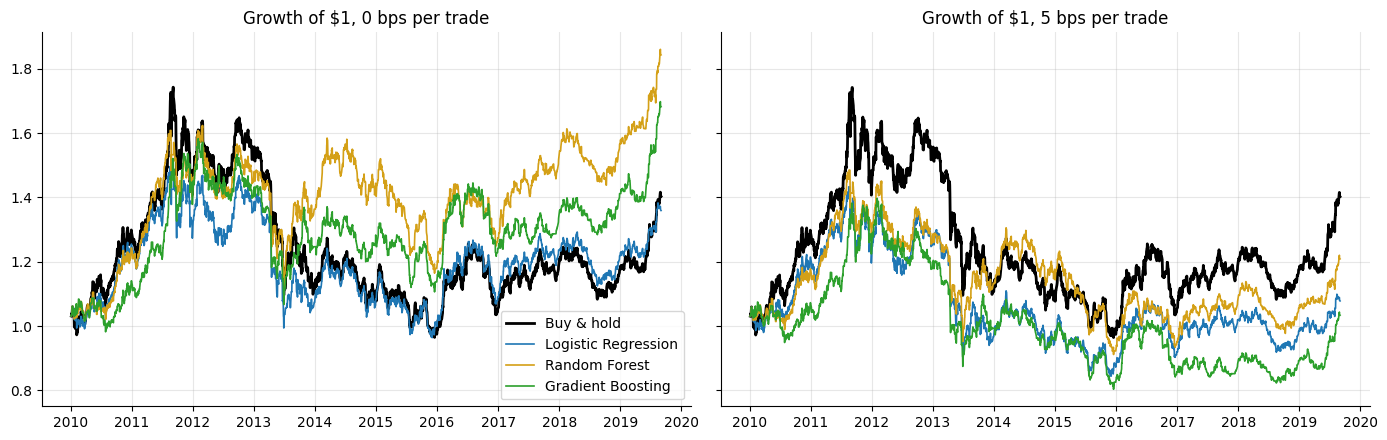

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, cost in zip(axes, (0, 5)):
    ax.plot(equity_curve(buy_and_hold(oos[MODEL_NAMES[0]]["return"], cost)), color="black", lw=2, label="Buy & hold")
    for name, color in zip(MODEL_NAMES[1:], ["tab:blue", GOLD, "tab:green"]):
        ax.plot(equity_curve(strategy_returns(oos[name], 0.5, cost)[0]), color=color, lw=1.2, label=name)
    ax.set(title=f"Growth of $1, {cost} bps per trade")
axes[0].legend()
plt.tight_layout(); plt.show()

## 5. How much do costs matter?

Find the per-trade cost at which the Random Forest strategy's CAGR drops to buy & hold's.

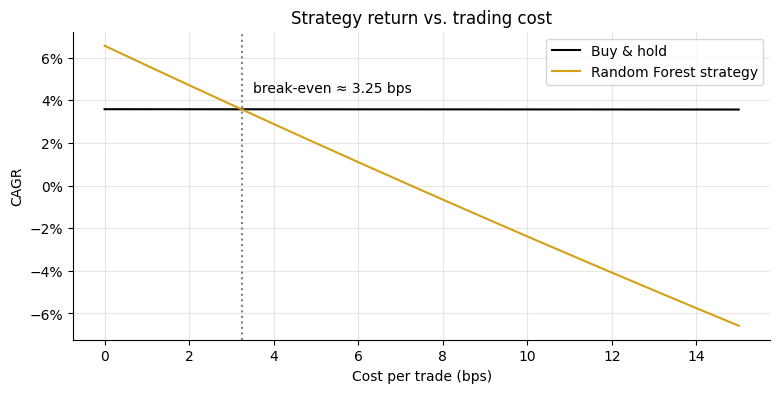

Random Forest trades ~88 times a year; edge over buy & hold is gone at ~3.25 bps per trade.


In [10]:
rf = oos["Random Forest"]
costs = np.arange(0, 15.01, 0.25)
rf_cagr = np.array([performance(strategy_returns(rf, 0.5, c)[0])["cagr"] for c in costs])
bh_cagr = np.array([performance(buy_and_hold(rf["return"], c))["cagr"] for c in costs])
break_even = costs[np.argmax(rf_cagr <= bh_cagr)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(costs, bh_cagr, color="black", label="Buy & hold")
ax.plot(costs, rf_cagr, color=GOLD, label="Random Forest strategy")
ax.axvline(break_even, ls=":", color="gray")
ax.annotate(f"break-even ≈ {break_even:g} bps", (break_even, bh_cagr[0]), xytext=(8, 12), textcoords="offset points")
ax.set(xlabel="Cost per trade (bps)", ylabel="CAGR", title="Strategy return vs. trading cost")
ax.yaxis.set_major_formatter("{x:.0%}")
ax.legend(); plt.show()

daily, position = strategy_returns(rf, 0.5, 0)
trades_per_year = performance(daily, position)["trades"] / (len(rf) / 252)
print(f"Random Forest trades ~{trades_per_year:.0f} times a year; edge over buy & hold is gone at ~{break_even:g} bps per trade.")

Retail gold ETF trading typically costs a few basis points per trade once spreads are included, so this strategy would not have survived contact with a real market.

## 6. Why a single test year is misleading

The original version of this project trained on 2001 to 2018 and tested on the 167 days of 2019, then invited the user to "adjust the sliders" until the model beat the market. Accuracy varies a lot from one year to the next, so any single year can make a model look great or terrible by chance:

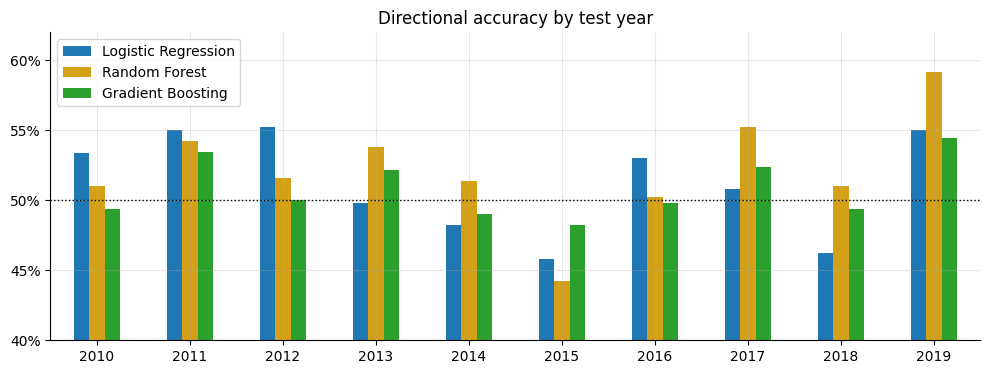

Random Forest yearly accuracy range: 44.2% to 59.2%


In [11]:
yearly = pd.DataFrame({
    name: ((o["proba_up"] > 0.5).astype(int) == o["target"]).groupby(o.index.year).mean()
    for name, o in oos.items() if name != MODEL_NAMES[0]
})
ax = yearly.plot.bar(color=["tab:blue", GOLD, "tab:green"], figsize=(12, 4), title="Directional accuracy by test year", rot=0)
ax.axhline(0.5, color="black", lw=1, ls=":")
ax.set(ylim=(0.4, 0.62), yticks=np.arange(0.40, 0.61, 0.05), xlabel="")
ax.yaxis.set_major_formatter("{x:.0%}")
plt.show()
print("Random Forest yearly accuracy range:", f"{yearly['Random Forest'].min():.1%} to {yearly['Random Forest'].max():.1%}")

Picking whichever slider setting beats the market on the test year is **tuning on the test set**. The resulting "edge" is selection bias, not skill. Walk-forward evaluation over many years with settings fixed in advance avoids this.

## 7. Conclusions

1. **Daily gold direction is close to unpredictable** from its own price history and the dollar's recent move. That is consistent with an efficient, heavily traded market.
2. **A model can look profitable before costs and still be useless.** The Random Forest's pre-cost Sharpe of 0.53 (vs 0.30) disappears at about 3 bps per trade.
3. **Evaluation design matters more than model choice.** Baselines, confidence intervals, walk-forward splits, leakage tests and costs turned an apparent "beats the market" result into an honest negative one.

**Possible extensions:** macro features (real yields, the DXY dollar index, VIX), weekly or monthly horizons where trend-following has more documented support, position sizing by predicted probability instead of all-or-nothing, and a statistical test for Sharpe-ratio differences (e.g. Ledoit–Wolf).